In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Toolik Transect Data and GAM analysis of NDVI drivers

1. Load data and calculate variables
2. Make plots
3. GAM analysis

# 1. Load Field Data

In [2]:
df = pd.read_csv('toolik_transects.csv')

### Create a column that contains the most abundant plant type at each point

plants identified as grass in the field were a subdivision of nontussock sedges (cottongrass). combine grass and nontussock sedge columns

In [3]:
# lump grass into nontussock sedge

# treat NA values as 0 for both SDG and GRS
df['SDG'] = df['SDG'].fillna(0) + df['GRS'].fillna(0)

'abund_spcs' is the plant type that had the most area cover at each point (%)

In [4]:
# abbreviations
species_map = {
    'TUSS': 'Tussock Sedge',
    'SDG': 'Nontussock Sedge',
    'SHR': 'Shrub',
    'ML': 'Moss and Lichen',
    'DRT': 'Bare Soil', # relabel 'Dirt' as 'Bare Soil'
    'FRB': 'Forbs'
}

# most abundant species column name for each row
abund_spcs_col = df[['TUSS', 'SDG','SHR', 'ML','DRT','FRB']].idxmax(axis=1)

# map column names to full species names
df['abund_spcs'] = abund_spcs_col.map(species_map)

### Create a soil temperature column 'Tsoil'

'T5cm': temperature taken at 5 cm depth. 
'Tald': temperature taken at active layer depth

In [5]:
# Tsoil = T5cm if ALD <= 5 cm. if not, then Tsoil = Tald
df['Tsoil'] = df['T5cm'].where(df['ALD'] >= 5, df['Tald'])

### Bin soil moisture

'SM': soil moisture sensor, ~60% VWC was the highest reading before sensor failure (saturated). 

'SW': surface water field observation. 0 = no SW, 1 = yes SW/ponding

In [6]:
bins = [0, 20, 40, 60]
labels = ['Dry','Moist','Wet']
df['SM_bin'] = pd.cut(df['SM'], bins=bins, labels=labels, right = False )

# if SW = 1, then SM_bin = 'Saturated'
df['SM_bin'] = np.where(df['SW'] == 1, 'Saturated', df['SM_bin'])

### Create a 'class2' column to lump points into intertrack or water track

In [7]:
# lump OR rename classes

df['class2'] = df['class']

df.loc[df['class'] == 'it', 'class2'] = 'Intertrack'

# points marked as channel or gully are included in water track class 
# channels/gullies were only classified at TGCs (track-gully complexes)
df.loc[df['class'].isin(['wt', 'chnl', 'gly']), 'class2'] = 'Water Track'

### Calculate relative incision using the average intertrack elevation

calculate average intertrack elevation for each transect. 

elevation data 

    TGC1: 2021-09-27 ArcticDEM
    TGC3 & TOOL280: field measured RTK GPS
    WT4 : Aug 2022 Toolik Field Station LiDAR survey

In [8]:
# map each site to its own elevation column
elev_col_map = {
    'TGC1':     'adem_20210927', # Arctic DEM
    'TGC3':     'rtk_elevation',
    'Tool280-1':  'rtk_elevation',
    'Tool280-2':  'rtk_elevation',
    'WT4':      'lidar_202208_dtm' # Toolik LiDAR DTM
}

# calculate elevation difference from intertrack average at each transect

# group by site and transect
for (site, transect), xs_df in df.groupby(['Site', 'Transect']):

    elev_col = elev_col_map[site]

    it_elev = xs_df.loc[xs_df['class2'] == 'Intertrack', elev_col].mean()

    fp_mask = xs_df['class2'] != 'Intertrack'
    df.loc[xs_df.index[fp_mask], 'it_elev_diff'] = (
        xs_df.loc[fp_mask, elev_col] - it_elev
    )


# 2. Make Plots

### Water track vs intertrack NDVI at each site

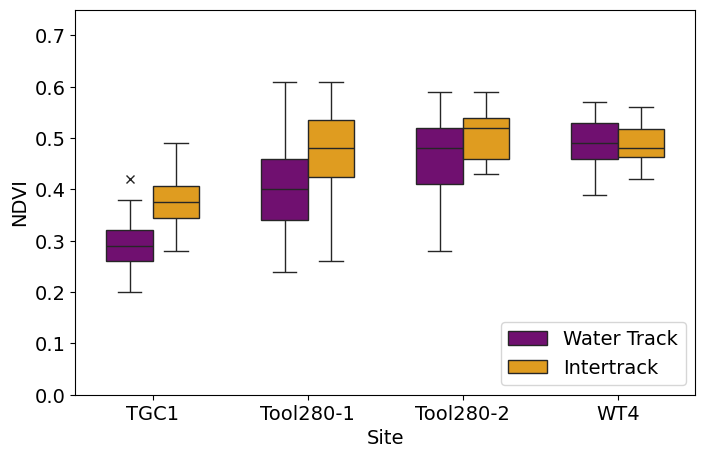

In [9]:
# exclude TGC3
df_no_tgc3 = df[df['Site'] != 'TGC3']

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_no_tgc3,
    x='Site', y='NDVI',
    hue='class2',                 # color by class
    hue_order=['Water Track', 'Intertrack'],   # order in legend & plotting
    palette={
        'Water Track': 'purple',
        'Intertrack': 'orange'
    },
    # remove outliers
    flierprops={"marker": "x"},
    width=0.6,
)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0,0.75)
plt.xlabel("Site", fontsize=14)
plt.ylabel("NDVI", fontsize=14)
plt.legend( fontsize = 14, loc='lower right', ncol = 1)
plt.show()

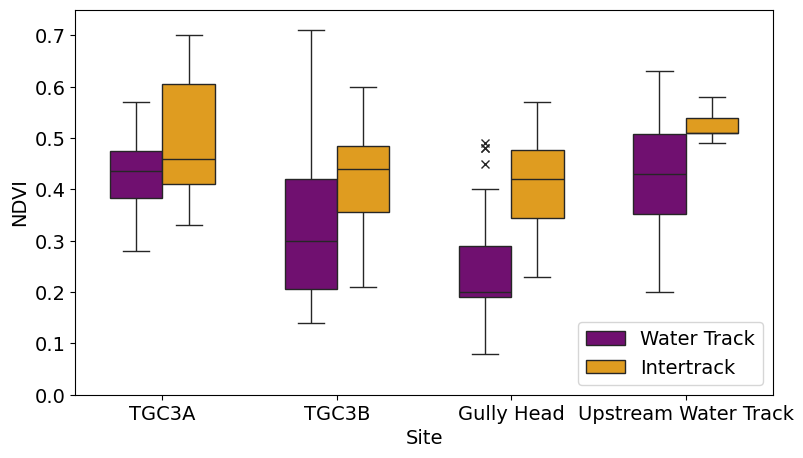

In [10]:
# just tgc3

tgc3 = df[df['Site'] == 'TGC3']

# transect 3 = Gully Head, transect 4 = Upstream Water Track
tgc3_map ={
    'TGC3A':'TGC3A',
    'TGC3B':'TGC3B',
    'TGC3-t3':'Gully Head',
    'TGC3-t4':'Upstream Water Track'
}

plt.figure(figsize=(9,5))

sns.boxplot(
    data=tgc3,
    x='tgc3_group', y='NDVI',
    order=tgc3_map.keys(),
    hue='class2',                 # color by class
    hue_order=['Water Track', 'Intertrack'],   # order in legend & plotting
    palette={
        'Water Track': 'purple',
        'Intertrack': 'orange'
    },
    # remove outliers
    flierprops={"marker": "x"},
    width=0.6,
)

x_label = tgc3_map.values() 
plt.xticks(range(len(x_label)), x_label, fontsize = 14)
plt.yticks(fontsize = 14)

plt.legend(fontsize = 14, loc='lower right', ncol = 1)

plt.ylim(0,0.75)
plt.xlabel("Site", fontsize=14)
plt.ylabel("NDVI", fontsize=14)
plt.show()


### Vegetation type pie charts for water track and intertrack at each site

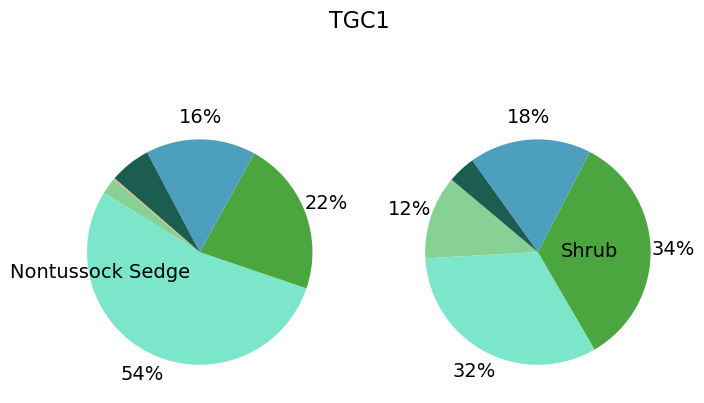

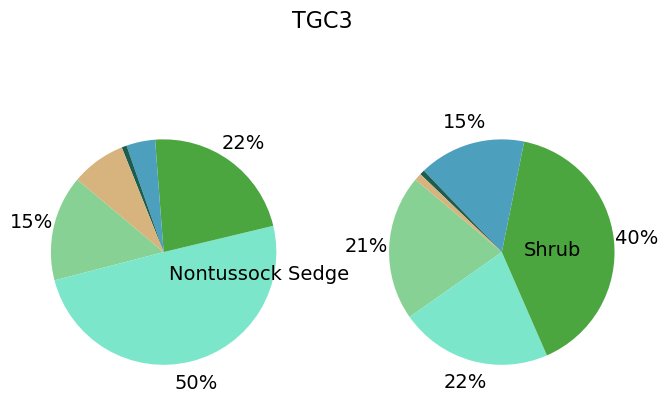

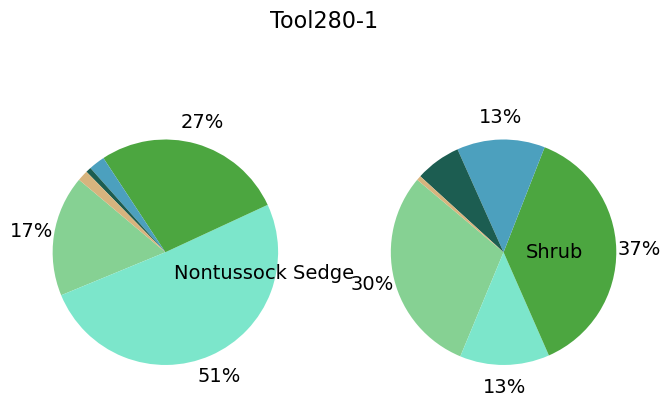

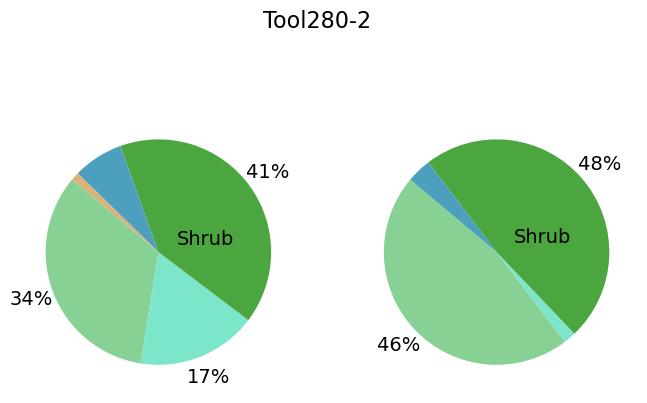

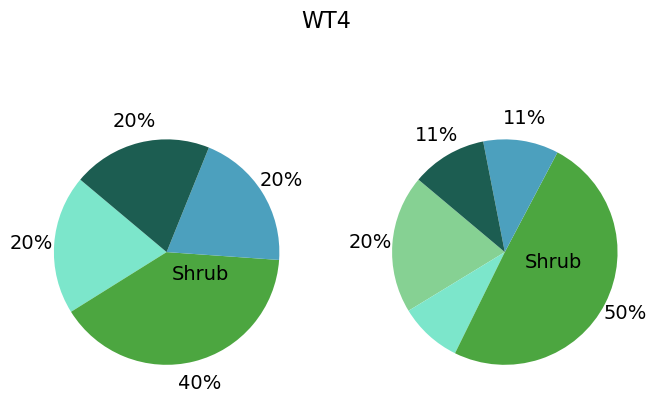

In [11]:
spcs_cols = ['TUSS','SDG','SHR', 'ML', 'FRB','DRT'
             ]

# abbreviations
labels = {
    'TUSS': 'Tussock Sedge',
    'SDG': 'Nontussock Sedge',
    'SHR': 'Shrub',
    'ML': 'Moss and Lichen',
    'DRT': 'Bare Soil',
    'FRB': 'Forbs'
}

# colors for pie chart
colors = {
    'TUSS': "#86d193",
    'SDG': "#7ce6cb",
    'SHR': "#4ca640",
    'ML': "#4ca0be",
    'DRT': "#d7b47e",
    'FRB': "#1c5d51"
}


sites = df['Site'].unique()
for site in sites:
    site_df = df[df['Site'] == site]
    
    fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(8, 5))

    # only label percentages above 10%
    def autopct_gt10(pct):
        return f'{pct:.0f}%' if pct >= 10 else '' # round to whole number, drop for % lower than 10


    for ax, fp in zip(axes, ['Water Track', 'Intertrack']): 
        # ordered so that water tracks are the left pie and intertracks are the right pie
        data = site_df[site_df['class2'] == fp]

        # get total counts for each species across all samples to identify dominant species
        values = data[spcs_cols].sum()
        max_idx = values.idxmax()
        pie_labels = [
            labels[c] if c == max_idx else ''
            for c in spcs_cols]

        wedges, texts, autotexts = ax.pie(
            data[spcs_cols].sum(),
            labels=pie_labels,
            labeldistance=0.2,
            autopct=autopct_gt10,
            pctdistance=1.2,
            colors=[colors[c] for c in spcs_cols],
            startangle=140,
            )

        for text in texts:
            text.set_fontsize(14)      # label fontsize
        for autotext in autotexts:
            autotext.set_fontsize(14)  # percentage fontsize

    fig.suptitle(site, fontsize=16)
    plt.show()


#### pie charts at transects of tgc3

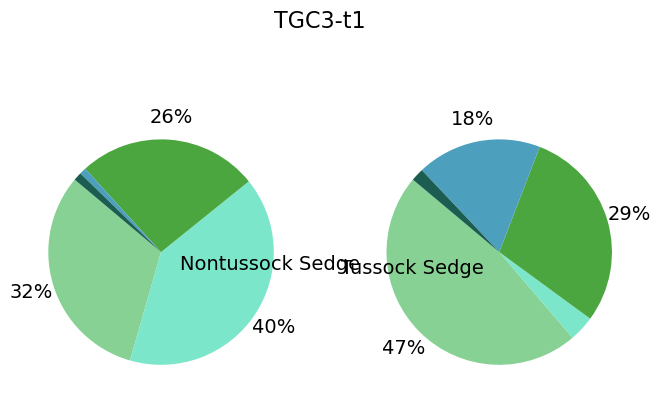

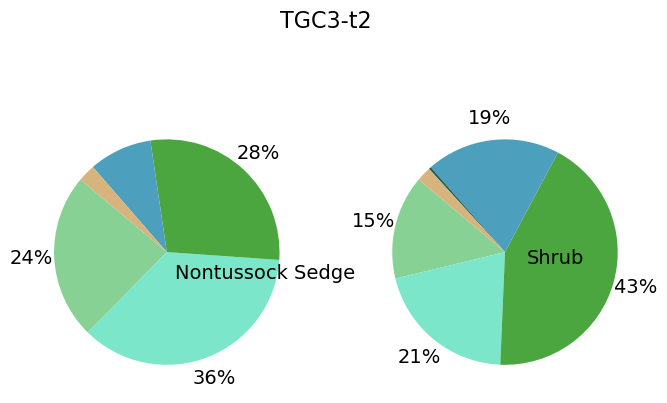

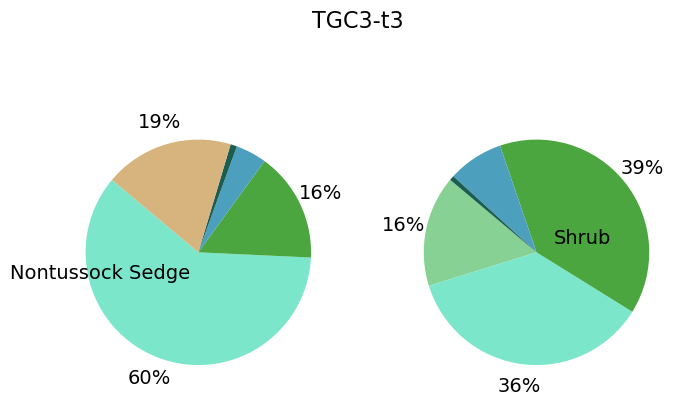

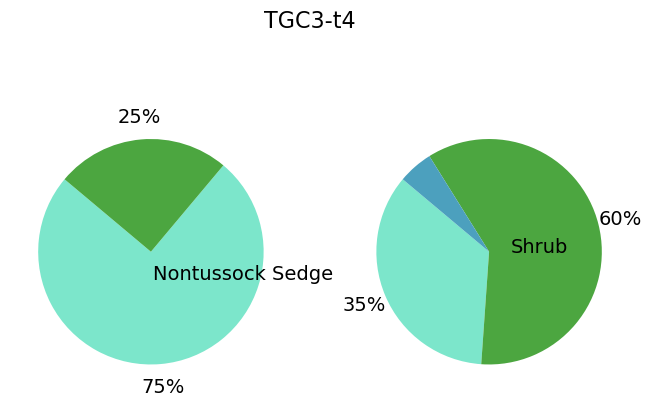

In [12]:
spcs_cols = ['TUSS','SDG','SHR', 'ML', 'FRB','DRT'
             ]

# abbreviations
labels = {
    'TUSS': 'Tussock Sedge',
    'SDG': 'Nontussock Sedge',
    'SHR': 'Shrub',
    'ML': 'Moss and Lichen',
    'DRT': 'Bare Soil',
    'FRB': 'Forbs'
}

# colors for pie chart
colors = {
    'TUSS': "#86d193",
    'SDG': "#7ce6cb",
    'SHR': "#4ca640",
    'ML': "#4ca0be",
    'DRT': "#d7b47e",
    'FRB': "#1c5d51"
}


transects = df[df['Site'] == 'TGC3']['Transect'].unique()
for transect in transects:
    transect_df = df[df['Transect'] == transect]
    
    fig, axes = plt.subplots(nrows=1, ncols = 2, figsize=(8, 5))

    # only label percentages above 10%
    def autopct_gt10(pct):
        return f'{pct:.0f}%' if pct >= 10 else '' # round to whole number, drop for % lower than 10


    for ax, fp in zip(axes, ['Water Track', 'Intertrack']): 
        # ordered so that water tracks are the left pie and intertracks are the right pie
        data = transect_df[transect_df['class2'] == fp]

        # get total counts for each species across all samples to identify dominant species
        values = data[spcs_cols].sum()
        max_idx = values.idxmax()
        pie_labels = [
            labels[c] if c == max_idx else ''
            for c in spcs_cols]

        wedges, texts, autotexts = ax.pie(
            data[spcs_cols].sum(),
            labels=pie_labels,
            labeldistance=0.2,
            autopct=autopct_gt10,
            pctdistance=1.2,
            colors=[colors[c] for c in spcs_cols],
            startangle=140,
            )

        for text in texts:
            text.set_fontsize(14)      # label fontsize
        for autotext in autotexts:
            autotext.set_fontsize(14)  # percentage fontsize

        fig.suptitle(transect, fontsize=16)


#### pie chart legend

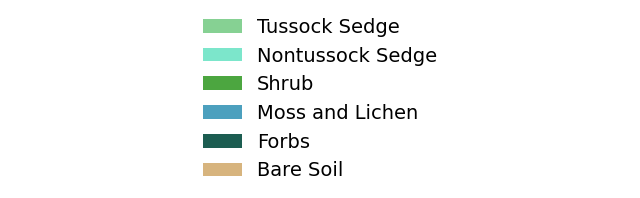

In [13]:
from matplotlib.patches import Patch

# create legend handles
legend_handles = [
    Patch(facecolor=colors[c], label=labels[c])
    for c in spcs_cols
]

# make a separate figure just for the legend
fig_legend, ax_legend = plt.subplots(figsize=(8, 1))
ax_legend.axis('off')  # hide axes

fig_legend.legend(
    handles=legend_handles,
    loc='center',
    frameon=False,
    ncol=1,
    fontsize=14)

### Heatmap of veg type, wetness, and greenness
- Vegetation type is the most abundant plant type at that point. Forbs is not included (n=1)
- Soil moisture classified as dry, < 20%; moist, 20-40%; wet, 40-60%; and saturated, where surface water was visually present.
- NDVI recorded in-situ.

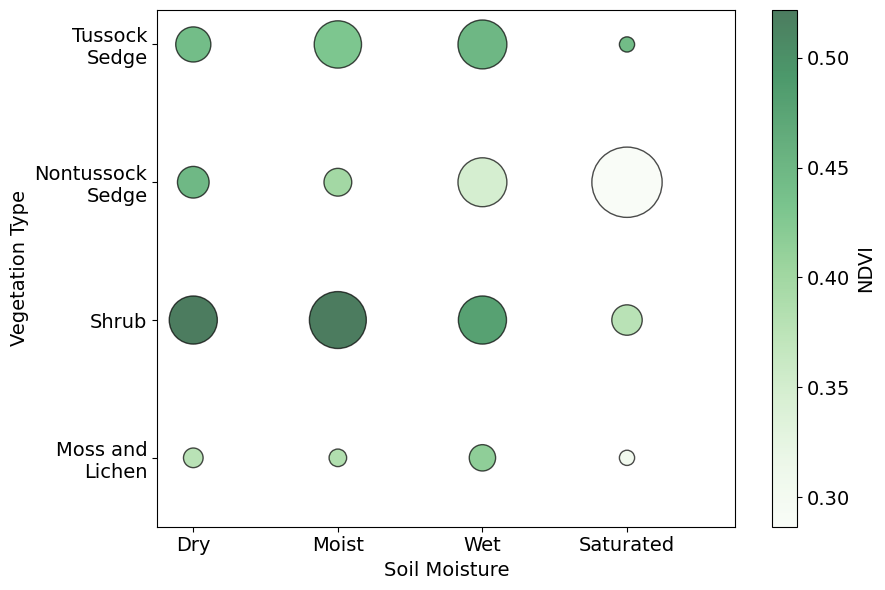

In [14]:
# list soil moisture and species categories in the order you want them to be plotted
sm_order = ['Dry', 'Moist', 'Wet', 'Saturated']
spcs_order = ['Tussock Sedge','Nontussock Sedge','Shrub','Moss and Lichen'] 
# removed forbs (n=1)

# count frequency of each category
ct = pd.crosstab(df['abund_spcs'], df['SM_bin'])
ct = ct.reindex(index=spcs_order, columns=sm_order)

# mean NDVI per category
ndvi_mean = df.groupby(['abund_spcs','SM_bin'])['NDVI'].mean().unstack()
ndvi_mean = ndvi_mean.reindex(index=spcs_order, columns=sm_order)

# set up x and y axis categories with values
x, y, sizes, colors = [], [], [], []
for i, spc in enumerate(spcs_order): # loop over species types
    for j, sm in enumerate(sm_order): # loop over soil moisture categories

        #retrieve counts and mean NDVI
        count = ct.loc[spc, sm] if sm in ct.columns else 0
        ndvi = ndvi_mean.loc[spc, sm] if sm in ndvi_mean.columns else np.nan
        
        x.append(j)          # soil moisture
        y.append(i)          # species 
        sizes.append(count*40)  # scale for bubble size
        colors.append(ndvi)  # bubble colored by NDVI 

# plot
plt.figure(figsize=(9,6))
scatter = plt.scatter(x, y, s=sizes, c=colors, cmap='Greens', alpha=0.7, edgecolor='k')

# ticks
y_label = ['Tussock\nSedge','Nontussock\nSedge','Shrub','Moss and\nLichen']
plt.xticks(range(len(sm_order)), sm_order, fontsize = 14)
plt.yticks(range(len(y_label)), y_label, fontsize = 14)

# make ticks closer
plt.xlim(-0.25, len(sm_order)-0.25)
plt.ylim(-0.25, len(spcs_order)-0.5)

# colorbar for NDVI
cbar = plt.colorbar(scatter)
cbar.set_label("NDVI",fontsize = 14)
cbar.ax.tick_params(labelsize=14)

plt.xlabel("Soil Moisture", fontsize = 14)
plt.ylabel("Vegetation Type",fontsize = 14)
plt.gca().invert_yaxis()  # match heatmap orientation
plt.tight_layout()
plt.show()

#### print value counts for each category

In [15]:
summary = pd.concat({'Count': ct, 'Mean NDVI': ndvi_mean}, axis=1)
summary.head()

Count                     Mean NDVI                      \
SM_bin             Dry Moist Wet Saturated       Dry     Moist       Wet   
abund_spcs                                                                 
Tussock Sedge       16    29  31         3  0.442500  0.430690  0.449677   
Nontussock Sedge    13    10  31        64  0.447692  0.398000  0.348065   
Shrub               30    42  30        12  0.521667  0.520952  0.479333   
Moss and Lichen      5     4   9         3  0.378000  0.385000  0.415556   

                            
SM_bin           Saturated  
abund_spcs                  
Tussock Sedge     0.443333  
Nontussock Sedge  0.286562  
Shrub             0.378333  
Moss and Lichen   0.303333

### Heatmap of geomorphic classification

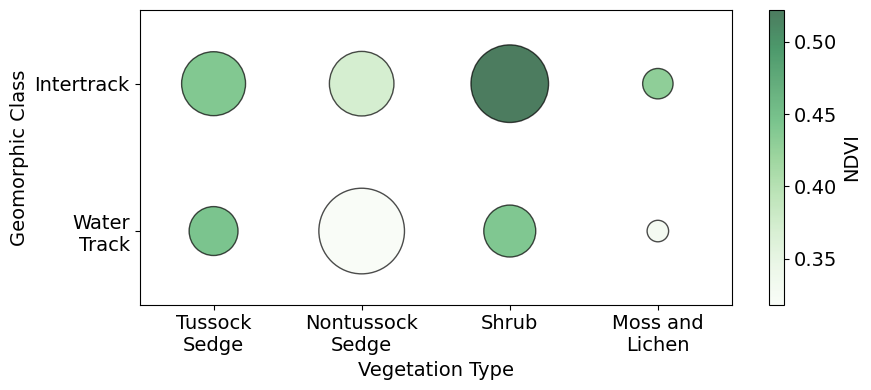

In [16]:
# scatter heatmap

# order axes 
x_order = ['Tussock Sedge','Nontussock Sedge','Shrub','Moss and Lichen'] # omit forbs (n=1)
y_order = ['Intertrack', 'Water Track'] # lumped gly and chnl into wt

# count frequency of each category
ct = pd.crosstab(df['class2'], df['abund_spcs']).reindex(index=y_order, columns=x_order)

# mean NDVI per category
ndvi_mean = df.groupby(['class2','abund_spcs'])['NDVI'].mean().unstack().reindex(index=y_order, columns=x_order)

# make df
data = pd.DataFrame({
    "x": np.tile(range(len(x_order)), len(y_order)),
    "y": np.repeat(range(len(y_order)), len(x_order)),
    "size": (ct.values.flatten() * 40),
    "color": ndvi_mean.values.flatten()})


# plot
plt.figure(figsize=(9,4))
scatter = plt.scatter(data["x"], data["y"],
    s=data["size"], c=data["color"],
    cmap='Greens', alpha=0.7, edgecolor='k'
)

# ticks
x_label = ['Tussock\nSedge','Nontussock\nSedge','Shrub','Moss and\nLichen'] 
y_label = ['Intertrack', 'Water\nTrack']
plt.xticks(range(len(x_label)), x_label, fontsize = 14)
plt.yticks(range(len(y_label)), y_label, fontsize = 14)

# make ticks closer
plt.xlim(-0.5, len(x_order)-0.5)
plt.ylim(-0.5, len(y_order)-0.5)

# colorbar for NDVI
cbar = plt.colorbar(scatter)
cbar.set_label("NDVI",fontsize = 14)
cbar.ax.tick_params(labelsize=14)

plt.xlabel("Vegetation Type", fontsize = 14)
plt.ylabel("Geomorphic Class",fontsize = 14)
plt.gca().invert_yaxis()  # match heatmap orientation
plt.tight_layout()
plt.show()


#### print value counts for each category

In [17]:
summary = pd.concat({'Count': ct, 'Mean NDVI': ndvi_mean}, axis=1)
summary.head()

Count                                         \
abund_spcs  Tussock Sedge Nontussock Sedge Shrub Moss and Lichen   
class2                                                             
Intertrack             53               54    78              12   
Water Track            31               95    35               6   

                Mean NDVI                                             
abund_spcs  Tussock Sedge Nontussock Sedge     Shrub Moss and Lichen  
class2                                                                
Intertrack       0.439811         0.370909  0.521923        0.430000  
Water Track      0.444194         0.318315  0.440571        0.328333

## Vegetation and Soil Moisture vs NDVI Boxplot

/tmp/ipykernel_408/1543688607.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


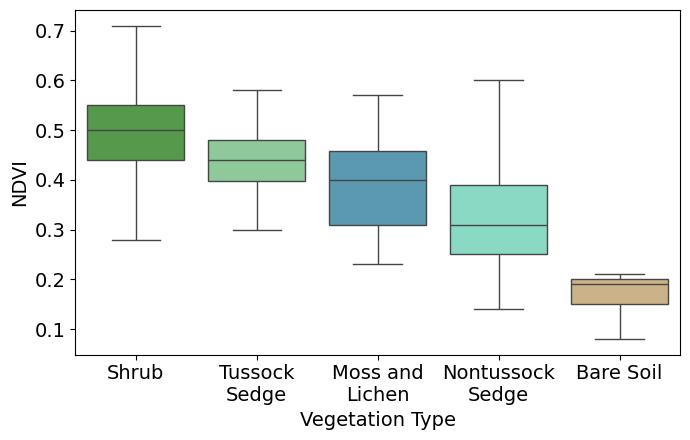

In [18]:
# vegetation 

colors = {
    'Tussock Sedge': "#86d193",
    'Nontussock Sedge': "#7ce6cb",
    'Shrub': "#4ca640",
    'Moss and Lichen': "#4ca0be",
    'Bare Soil': "#d7b47e",
}

plt.figure(figsize=(7, 4.5))

sns.boxplot(
    data=df,
    x='abund_spcs',
    y='NDVI',
    palette=colors,
    order=['Shrub', 'Tussock Sedge', 'Moss and Lichen', 'Nontussock Sedge', 'Bare Soil'],
    showfliers=False
)

x_label = ['Shrub', 'Tussock\nSedge', 'Moss and\nLichen', 'Nontussock\nSedge', 'Bare Soil']
plt.xticks(ticks=range(5), labels=x_label, fontsize=14)
plt.xlabel("Vegetation Type", fontsize=14)
plt.ylabel("NDVI", fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

/tmp/ipykernel_408/857374760.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='SM_bin', y='NDVI', palette='Blues',


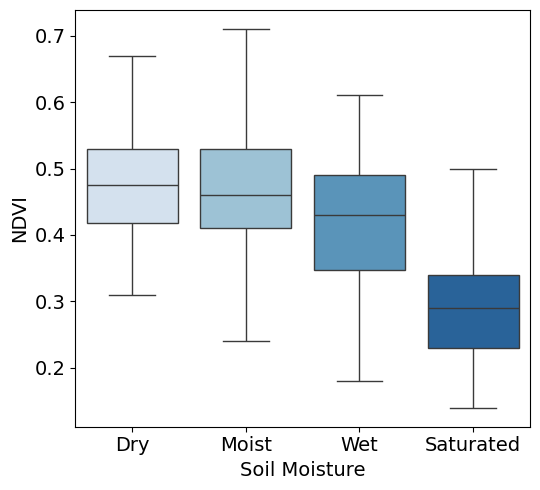

In [19]:
# Soil Moisture

plt.figure(figsize=(5.5, 5))

sns.boxplot(data=df, x='SM_bin', y='NDVI', palette='Blues',
            order=['Dry', 'Moist', 'Wet', 'Saturated'],
            showfliers=False) 

plt.xlabel("Soil Moisture", fontsize=14)
plt.ylabel("NDVI", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.show()

# Track-Intertrack NDVI of Toolik Sites from 2019-2025, Sentinel-2 and field data

load remote data
- 'ndvi_mean_wt'= mean NDVI of pixels within water track AOI from Sentinel-2 (10-m) imagery
- 'ndvi_mean_it'= mean NDVI of pixels within intertrack AOI from Sentinel-2 from Sentinel-2 (10-m) imagery
- Date = Image date
- site = Toolik Field Site

In [20]:
ndvi = pd.read_csv('toolik_ndvi_19-25.csv') # load csv

calculate field NDVI mean values in the water track and intertrack at each site

In [21]:
sites = df['Site'].unique()

rows = []

for site in sites:
    site_df = df[df['Site'] == site]

    wt = site_df.loc[site_df['class2'] == 'Water Track', 'NDVI']
    it = site_df.loc[site_df['class2'] == 'Intertrack', 'NDVI']

    rows.append({
        'Site': site,
        # calculate mean NDVI
        'ndvi_mean_wt': wt.mean(),
        'ndvi_mean_it': it.mean(),
        # calculate standard error 
        'ndvi_se_wt': wt.std() / np.sqrt(wt.count()),
        'ndvi_se_it': it.std() / np.sqrt(it.count()),
    })

field_ndvi = pd.DataFrame(rows)

add date of field data collection

In [22]:
date_map = {
    'TGC1': '06-22-2025',
    'WT4': '06-22-2025',
    'TGC3': '06-21-2025',
    'Tool280-1': '06-24-2025',
    'Tool280-2': '06-24-2025',
}

field_ndvi['date'] = field_ndvi['Site'].map(date_map)

convert image and field data dates to datetime, find day of year (DOY), and year. then calculate NDVI ratio

In [23]:
for data in [ndvi, field_ndvi]:
    data['date'] = pd.to_datetime(data['date'])
    data['doy'] = data['date'].dt.dayofyear
    data['year'] = data['date'].dt.year
    data['ndvi_ratio'] = data['ndvi_mean_wt'] / data['ndvi_mean_it']

# standard error for field ndvi ratio
field_ndvi['ndvi_ratio_se'] = field_ndvi['ndvi_ratio'] * np.sqrt(
    (field_ndvi['ndvi_se_wt'] / field_ndvi['ndvi_mean_wt'])**2 +
    (field_ndvi['ndvi_se_it'] / field_ndvi['ndvi_mean_it'])**2
)

plot subplots for each site with remote values in circles, field data as star

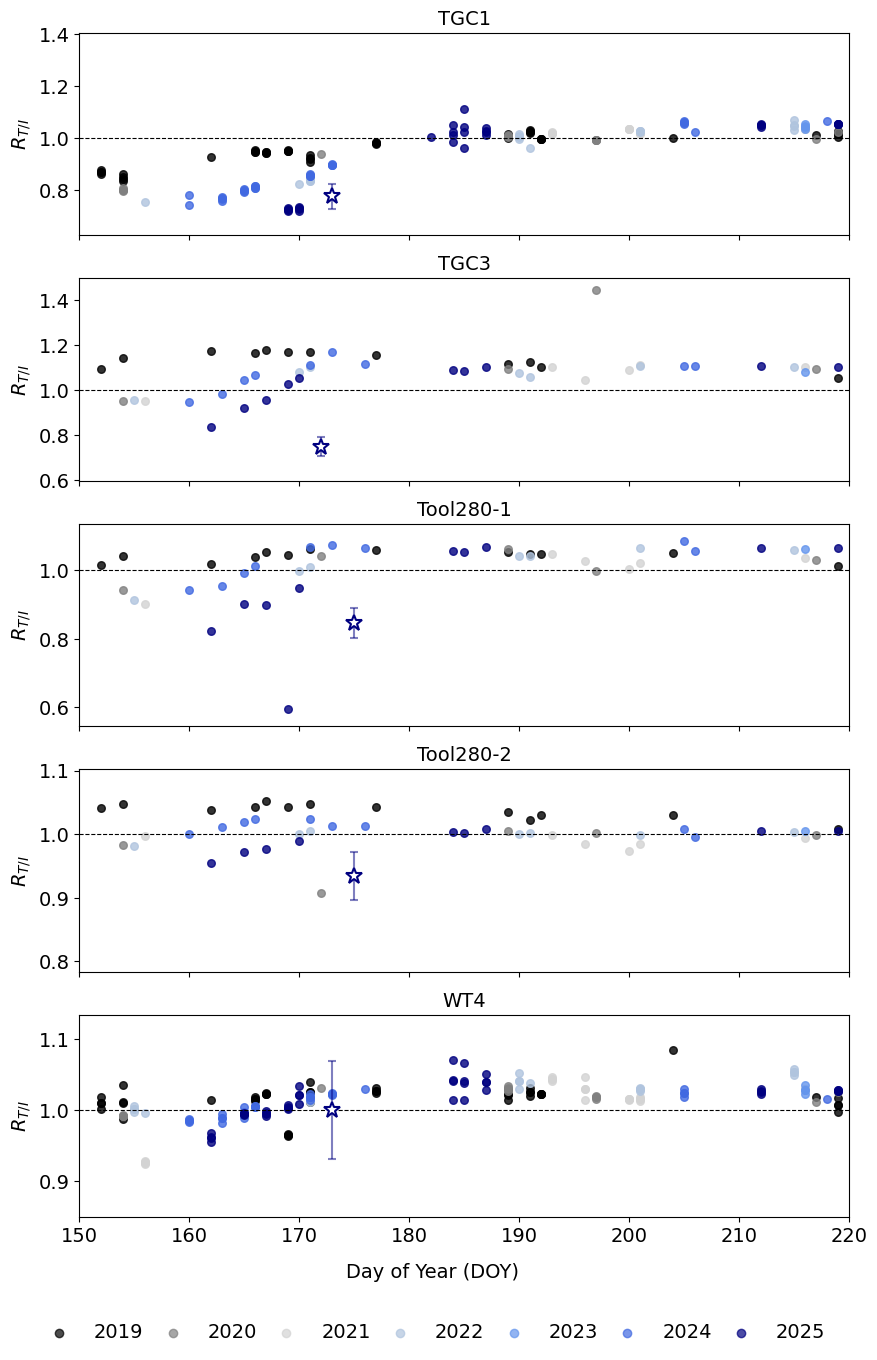

In [24]:
# plot with subplots for each site

colors = {
    2019: 'black',
    2020: 'gray',
    2021: 'lightgray',
    2022: 'lightsteelblue',
    2023: 'cornflowerblue',
    2024: 'royalblue',
    2025: 'navy'
}

sites = sorted(ndvi['Site'].unique())

fig, axes = plt.subplots(len(sites), 1, figsize=(9, 13), sharex=True)
axes = axes.flatten()

for i, site_name in enumerate(sites):
    data = ndvi[ndvi['Site'] == site_name]
    field_data = field_ndvi[field_ndvi['Site'] == site_name]

    ax = axes[i]

    # plot remote data as circles
    for year, group in data.groupby('year'):
        ax.scatter(group['doy'], group['ndvi_ratio'], label=year,
                   color=colors.get(year, 'gray'), alpha=0.8,s = 30)

    # plot field data as stars with error bars
    for year, group in field_data.groupby('year'):
        ax.errorbar(group['doy'], group['ndvi_ratio'],
            yerr=group['ndvi_ratio_se'],
            fmt='*',
            markerfacecolor='white',
            markeredgecolor=colors.get(year, 'gray'),
            markeredgewidth=1.5,
            markersize=12,
            ecolor=(colors.get(year, 'gray'), 0.5), # alpha = 0.5
            elinewidth=1.5,
            capsize=3,
            zorder=5)

    # add dashed line where ndvi ratio = 1
    ax.axhline(y=1, color='black', linestyle='--', linewidth=0.8)

    ymin = min(np.nanmin(data['ndvi_ratio']), np.nanmin(field_data['ndvi_ratio']) - 0.1)
    ymax = np.nanmax(data['ndvi_ratio'])
    ax.set_ylim(ymin - 0.05, ymax + 0.05)
    ax.set_xlim(150,220) # growing season time of interest

    ax.tick_params(axis='both', labelsize=14)

    ax.set_title(site_name, fontsize = 14)
    ax.set_ylabel(r'$R_{T/I}$', fontsize = 14)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

# label x axis for entire figure
fig.supxlabel('Day of Year (DOY)', fontsize=14) 

#legend
handles = [plt.scatter([], [], color=colors[year], alpha=0.7, label=year) for year in sorted(colors)]
fig.legend(handles=handles, loc='lower center', ncols=7, bbox_to_anchor=(0.5, -0.05),
           fontsize=14, title_fontsize=9, frameon=False, columnspacing=0.5
           )

plt.tight_layout()
plt.show()

# 3. GAM analysis of NDVI drivers

**Response variable**: NDVI  
**Sites**: TGC1, TGC3, Tool280-1, Tool280-2, WT4  
**Approach**: Generalized Additive Model (Gaussian, identity link) with penalized B-splines for continuous predictors, parametric terms for categorical predictors, and site included as a fixed effect.

### 1. Imports

In [25]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms
from matplotlib.lines import Line2D
from scipy import stats
import statsmodels.api as sm
from statsmodels.gam.api import GLMGam, BSplines
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score

# Figure pub settings
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

SEED = 42
rng = np.random.default_rng(SEED)

### 2. Data preparation

make sure df is loaded and all of section 1 is run

In [26]:
df_raw = df # save raw data

In [27]:
# Select modeling columns and drop incomplete rows
model_cols = ['Easting', 'Northing', 'NDVI', 'ALD', 'Tsoil',
              'it_elev_diff', 'SM_bin', 'abund_spcs', 'Site']

df = df_raw[model_cols].dropna().copy()
df['SM_bin']     = pd.Categorical(df['SM_bin'],     categories=['Dry','Moist','Wet','Saturated'], ordered=False)
df['abund_spcs'] = pd.Categorical(df['abund_spcs'], categories=['Bare Soil','Moss and Lichen','Nontussock Sedge','Shrub','Tussock Sedge'], ordered=False)
df['Site']       = pd.Categorical(df['Site'])

print(f'Analysis dataset: n = {len(df)} observations')
print()
print('SM_bin (n per category):')
print(df['SM_bin'].value_counts().to_string())
print()
print('Dominant vegetation (n per category):')
print(df['abund_spcs'].value_counts().to_string())
print()
print('Site (n per site):')
print(df['Site'].value_counts().to_string())

Analysis dataset: n = 142 observations

SM_bin (n per category):
SM_bin
Saturated    57
Wet          55
Moist        18
Dry          12

Dominant vegetation (n per category):
abund_spcs
Nontussock Sedge    69
Shrub               35
Tussock Sedge       24
Moss and Lichen      9
Bare Soil            5

Site (n per site):
Site
TGC1         53
TGC3         50
Tool280-1    19
Tool280-2    15
WT4           5


### 3. Exploratory data analysis

In [28]:
# Continuous predictor summaries and correlations
cont_cols = ['NDVI', 'it_elev_diff', 'Tsoil', 'ALD']
print('Descriptive statistics:')
print(df[cont_cols].describe().round(3).to_string())
print()
print('Correlation matrix (continuous predictors + NDVI):')
print(df[cont_cols].corr().round(3).to_string())
print()
print('NOTE: ALD–Tsoil correlation = {:.3f} — collinearity is present.'.format(
    df['ALD'].corr(df['Tsoil'])))
print('Both are retained; ALD is penalized toward linear by optimizer (alpha >> 1).')

Descriptive statistics:
          NDVI  it_elev_diff    Tsoil      ALD
count  142.000       142.000  142.000  142.000
mean     0.361        -0.289    2.247   13.254
std      0.115         0.509    2.403    8.194
min      0.080        -1.454   -0.600    0.000
25%      0.280        -0.585    0.025    7.000
50%      0.350        -0.190    1.700   12.500
75%      0.460        -0.016    3.900   18.000
max      0.650         1.046    9.900   36.000

Correlation matrix (continuous predictors + NDVI):
               NDVI  it_elev_diff  Tsoil    ALD
NDVI          1.000         0.031  0.038  0.031
it_elev_diff  0.031         1.000 -0.279 -0.308
Tsoil         0.038        -0.279  1.000  0.766
ALD           0.031        -0.308  0.766  1.000

NOTE: ALD–Tsoil correlation = 0.766 — collinearity is present.
Both are retained; ALD is penalized toward linear by optimizer (alpha >> 1).


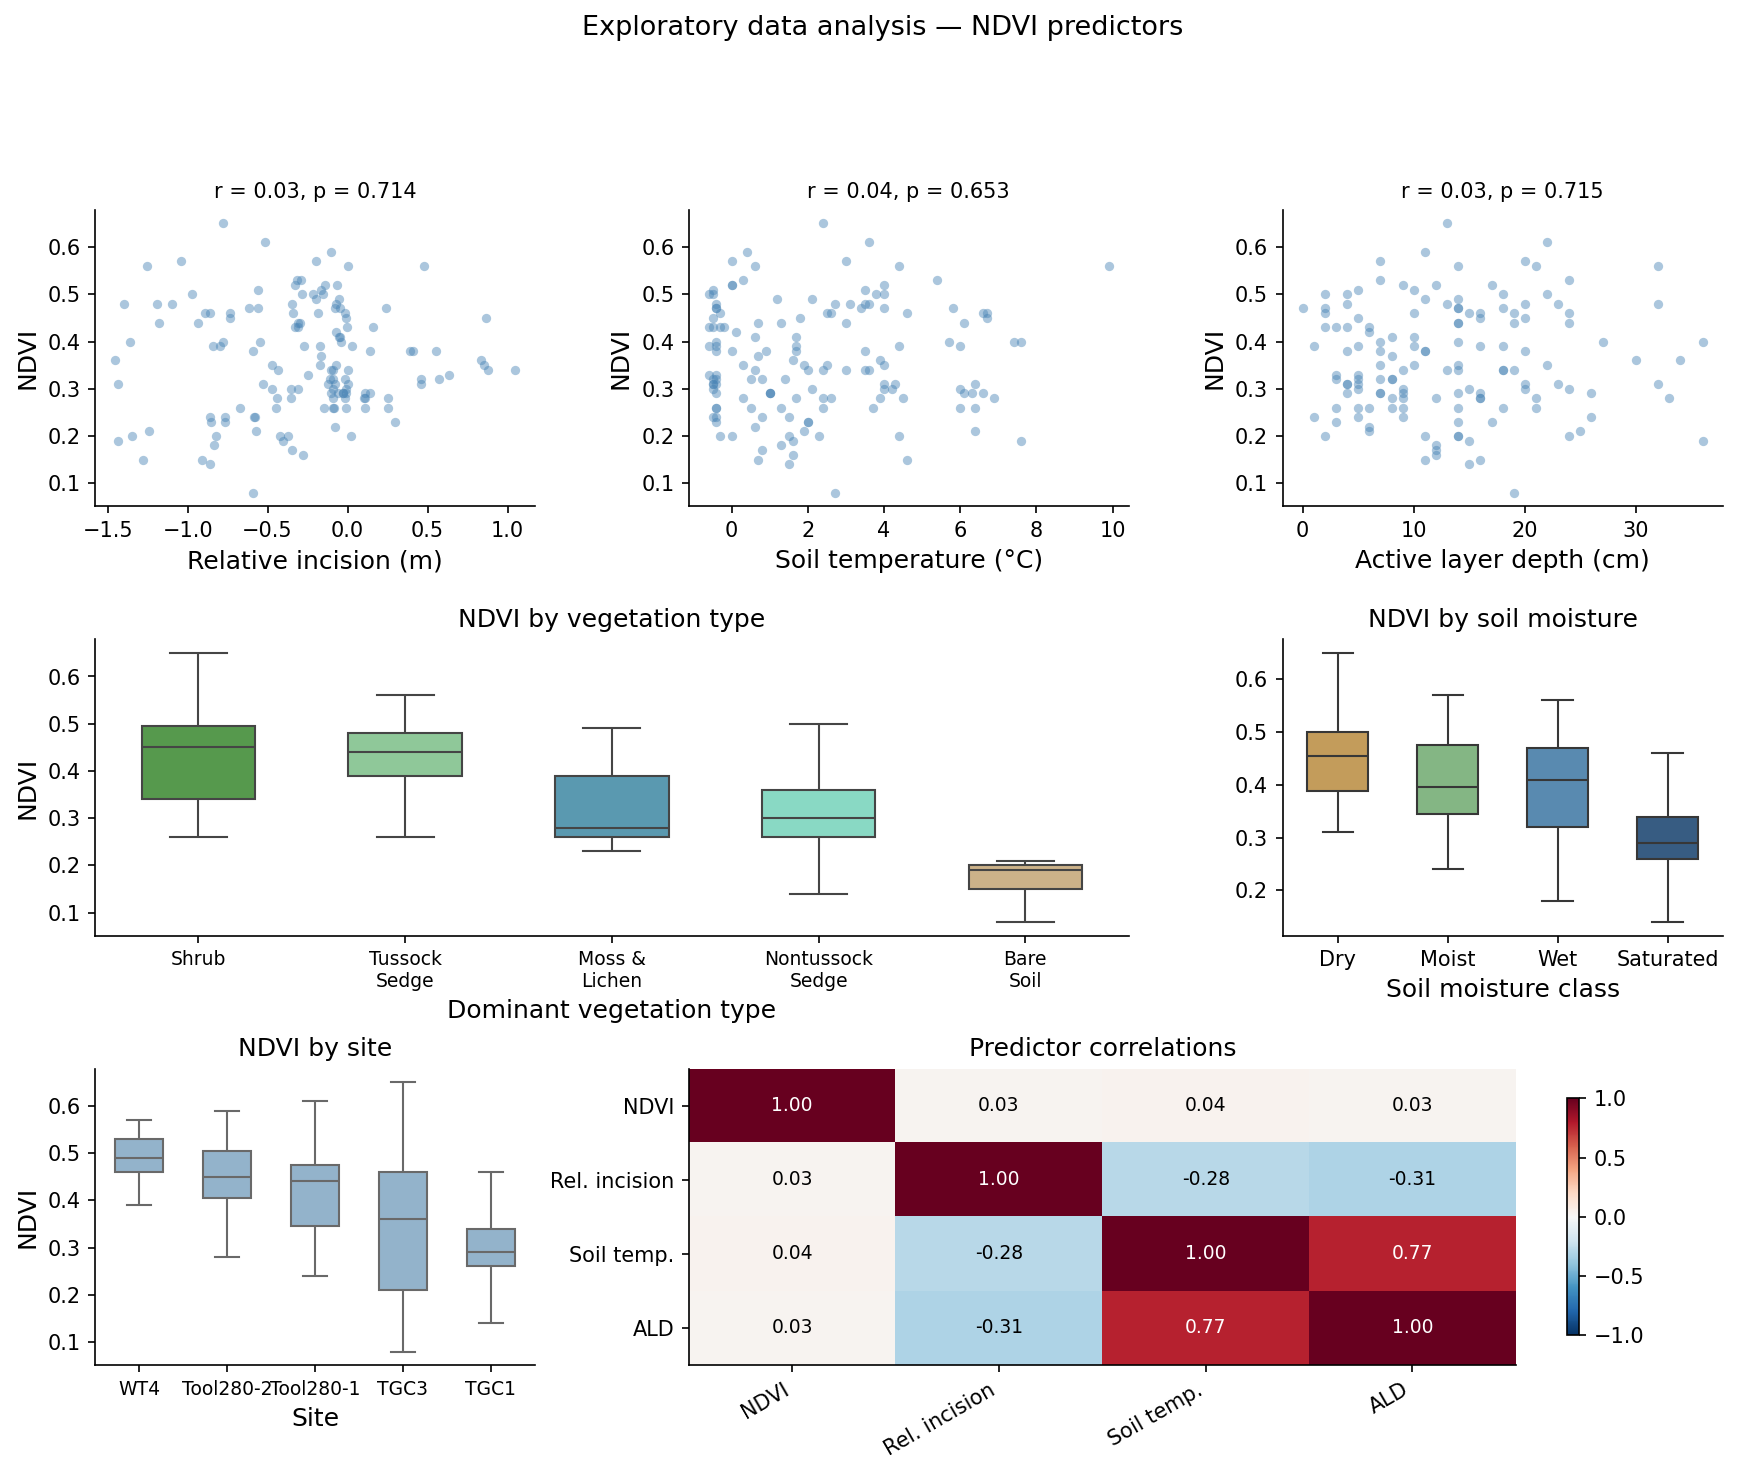

Saved: fig_eda.png


In [29]:
# Exploratory Data Aanalysis Figure = distributions, scatter, and categorical means
veg_order = ['Shrub', 'Tussock Sedge', 'Moss and Lichen', 'Nontussock Sedge', 'Bare Soil']
sm_order  = ['Dry', 'Moist', 'Wet', 'Saturated']

veg_colors = {
    'Shrub':            '#4ca640',
    'Tussock Sedge':    '#86d193',
    'Moss and Lichen':  '#4ca0be',
    'Nontussock Sedge': '#7ce6cb',
    'Bare Soil':        '#d7b47e',
}
sm_colors = {
    'Dry':       '#d4a04a',
    'Moist':     '#7cbe7c',
    'Wet':       '#4a8cbf',
    'Saturated': '#2a5c8f',
}

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

#===========
# Row 1 == continuous scatter plots
#===========
for col_i, (xvar, xlabel) in enumerate([
    ('it_elev_diff', 'Relative incision (m)'),
    ('Tsoil',        'Soil temperature (°C)'),
    ('ALD',          'Active layer depth (cm)'),
]):
    ax = fig.add_subplot(gs[0, col_i])
    ax.scatter(df[xvar], df['NDVI'], alpha=0.45, s=20,
               color='steelblue', linewidths=0)
    r, p = stats.pearsonr(df[xvar], df['NDVI'])
    ax.set_xlabel(xlabel)
    ax.set_ylabel('NDVI')
    ax.set_title(f'r = {r:.2f}, p = {p:.3f}', fontsize=10)

#===========
# Row 2 ==  vegetation boxplot (wide) + SM boxplot
#===========
ax_veg = fig.add_subplot(gs[1, :2])
sns.boxplot(data=df, x='abund_spcs', y='NDVI',
            order=veg_order, palette=veg_colors,
            showfliers=False, width=0.55, ax=ax_veg)
ax_veg.set_xticklabels(['Shrub', 'Tussock\nSedge', 'Moss &\nLichen',
                         'Nontussock\nSedge', 'Bare\nSoil'], fontsize=9)
ax_veg.set_xlabel('Dominant vegetation type')
ax_veg.set_ylabel('NDVI')
ax_veg.set_title('NDVI by vegetation type')

ax_sm = fig.add_subplot(gs[1, 2])
sns.boxplot(data=df, x='SM_bin', y='NDVI',
            order=sm_order, palette=sm_colors,
            showfliers=False, width=0.55, ax=ax_sm)
ax_sm.set_xlabel('Soil moisture class')
ax_sm.set_ylabel('')
ax_sm.set_title('NDVI by soil moisture')

#===========
# Row 3 == NDVI by site + predictor correlation heatmap
#===========
ax_site = fig.add_subplot(gs[2, 0])
site_order = df.groupby('Site')['NDVI'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Site', y='NDVI', order=site_order,
            color='#8ab4d4', showfliers=False, width=0.55, ax=ax_site)
ax_site.set_xlabel('Site')
ax_site.set_ylabel('NDVI')
ax_site.set_title('NDVI by site')
ax_site.tick_params(axis='x', labelsize=9)

ax_corr = fig.add_subplot(gs[2, 1:])
corr_m = df[['NDVI', 'it_elev_diff', 'Tsoil', 'ALD']].corr()
corr_labels = ['NDVI', 'Rel. incision', 'Soil temp.', 'ALD']
im = ax_corr.imshow(corr_m, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax_corr.set_xticks(range(4)); ax_corr.set_xticklabels(corr_labels, rotation=30, ha='right')
ax_corr.set_yticks(range(4)); ax_corr.set_yticklabels(corr_labels)
for i in range(4):
    for j in range(4):
        ax_corr.text(j, i, f'{corr_m.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9,
                     color='white' if abs(corr_m.iloc[i,j]) > 0.5 else 'black')
plt.colorbar(im, ax=ax_corr, shrink=0.8)
ax_corr.set_title('Predictor correlations')

plt.suptitle('Exploratory data analysis — NDVI predictors', y=1.01, fontsize=13)
plt.savefig('fig_eda.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: fig_eda.png')

### 4. Model selection by AIC

Four candidate models are compared. Smoothing penalties (alpha) are optimized via GCV (`select_penweight()`) for each model independently.

In [30]:
def fit_gam(formula, smooth_cols, df_data, n_knots=4):
    """Fit a GLMGam, optimize alpha via GCV, and return the optimized result."""
    x = df_data[smooth_cols].values
    smoother = BSplines(x, df=[n_knots]*len(smooth_cols), degree=[3]*len(smooth_cols))
    
    # Initial fit to enable select_penweight
    gam_init = GLMGam.from_formula(formula, data=df_data, smoother=smoother,
                                   alpha=[1.0]*len(smooth_cols))
    gam_init.fit()  # required for select_penweight to work
    opt_alpha = gam_init.select_penweight()[0]
    
    # Refit with optimal alpha
    gam_opt = GLMGam.from_formula(formula, data=df_data, smoother=smoother,
                                  alpha=opt_alpha)
    result = gam_opt.fit()
    return result, opt_alpha, smoother


base_formula_no_site = (
    'NDVI ~ C(SM_bin, Treatment("Dry")) + C(abund_spcs, Treatment("Bare Soil")) + '
    '{smooth_terms}'
)
base_formula_site = (
    'NDVI ~ C(SM_bin, Treatment("Dry")) + C(abund_spcs, Treatment("Bare Soil")) + '
    'C(Site, Treatment("TGC1")) + {smooth_terms}'
)

models = {}

print('Fitting candidate models (GCV alpha optimization per model)...')

#===========
# M1 == no ALD, no Site
#===========
formula_m1 = base_formula_no_site.format(smooth_terms='it_elev_diff + Tsoil')
m1_res, m1_alpha, m1_sp = fit_gam(formula_m1, ['it_elev_diff', 'Tsoil'], df)
models['M1'] = {'result': m1_res, 'alpha': m1_alpha, 'smoother': m1_sp,
                'desc': 's(elev) + s(Tsoil) + SM + Veg'}

#===========
# M2 == ALD, no Site
#===========
formula_m2 = base_formula_no_site.format(smooth_terms='it_elev_diff + Tsoil + ALD')
m2_res, m2_alpha, m2_sp = fit_gam(formula_m2, ['it_elev_diff', 'Tsoil', 'ALD'], df)
models['M2'] = {'result': m2_res, 'alpha': m2_alpha, 'smoother': m2_sp,
                'desc': 's(elev) + s(Tsoil) + s(ALD) + SM + Veg'}

#===========
# M3 == no ALD, with Site
#===========
formula_m3 = base_formula_site.format(smooth_terms='it_elev_diff + Tsoil')
m3_res, m3_alpha, m3_sp = fit_gam(formula_m3, ['it_elev_diff', 'Tsoil'], df)
models['M3'] = {'result': m3_res, 'alpha': m3_alpha, 'smoother': m3_sp,
                'desc': 's(elev) + s(Tsoil) + SM + Veg + Site'}

#===========
# M4 == ALD + Site (selected model)
#===========

# Post hoc note is this was the best performing model and was selected
formula_m4 = base_formula_site.format(smooth_terms='it_elev_diff + Tsoil + ALD')
m4_res, m4_alpha, m4_sp = fit_gam(formula_m4, ['it_elev_diff', 'Tsoil', 'ALD'], df)
models['M4'] = {'result': m4_res, 'alpha': m4_alpha, 'smoother': m4_sp,
                'desc': 's(elev) + s(Tsoil) + s(ALD) + SM + Veg + Site  ← selected'}

print()
print(f'{"Model":<5} {"AIC":>10}  {"ΔAIC":>8}  Description')
print('-' * 70)
aic_m1 = models['M1']['result'].aic
for name, m in models.items():
    aic = m['result'].aic
    delta = aic - aic_m1
    marker = ' *' if name == 'M4' else ''
    print(f'{name:<5} {aic:>10.2f}  {delta:>8.2f}  {m["desc"]}{marker}')

Fitting candidate models (GCV alpha optimization per model)...

Model        AIC      ΔAIC  Description
----------------------------------------------------------------------
M1       -288.32      0.00  s(elev) + s(Tsoil) + SM + Veg
M2       -291.34     -3.03  s(elev) + s(Tsoil) + s(ALD) + SM + Veg
M3       -318.29    -29.97  s(elev) + s(Tsoil) + SM + Veg + Site
M4       -322.00    -33.68  s(elev) + s(Tsoil) + s(ALD) + SM + Veg + Site  ← selected *


### 5. Final Model (M4) — summary and diagnostics

In [31]:
# Convenience references to selected model
res  = m4_res
sp   = m4_sp

print('=' * 70)
print('SELECTED MODEL — M4')
print('=' * 70)
print(res.summary())
print()
print(f'Optimal smoothing penalties (alpha): {[f"{a:.4f}" for a in m4_alpha]}')
print('  Columns: [it_elev_diff, Tsoil, ALD]')
print()
print('Interpretation note: large alpha for ALD indicates the smooth is')
print('penalized toward linearity — consistent with high collinearity with Tsoil.')

SELECTED MODEL — M4
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   NDVI   No. Observations:                  142
Model:                         GLMGam   Df Residuals:                   122.06
Model Family:                Gaussian   Df Model:                        18.94
Link Function:               Identity   Scale:                       0.0053267
Method:                         PIRLS   Log-Likelihood:                 180.94
Date:                Wed, 17 Jun 2026   Deviance:                      0.65019
Time:                        22:43:56   Pearson chi2:                    0.650
No. Iterations:                     3   Pseudo R-squ. (CS):             0.8028
Covariance Type:            nonrobust                                         
                                                                coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------

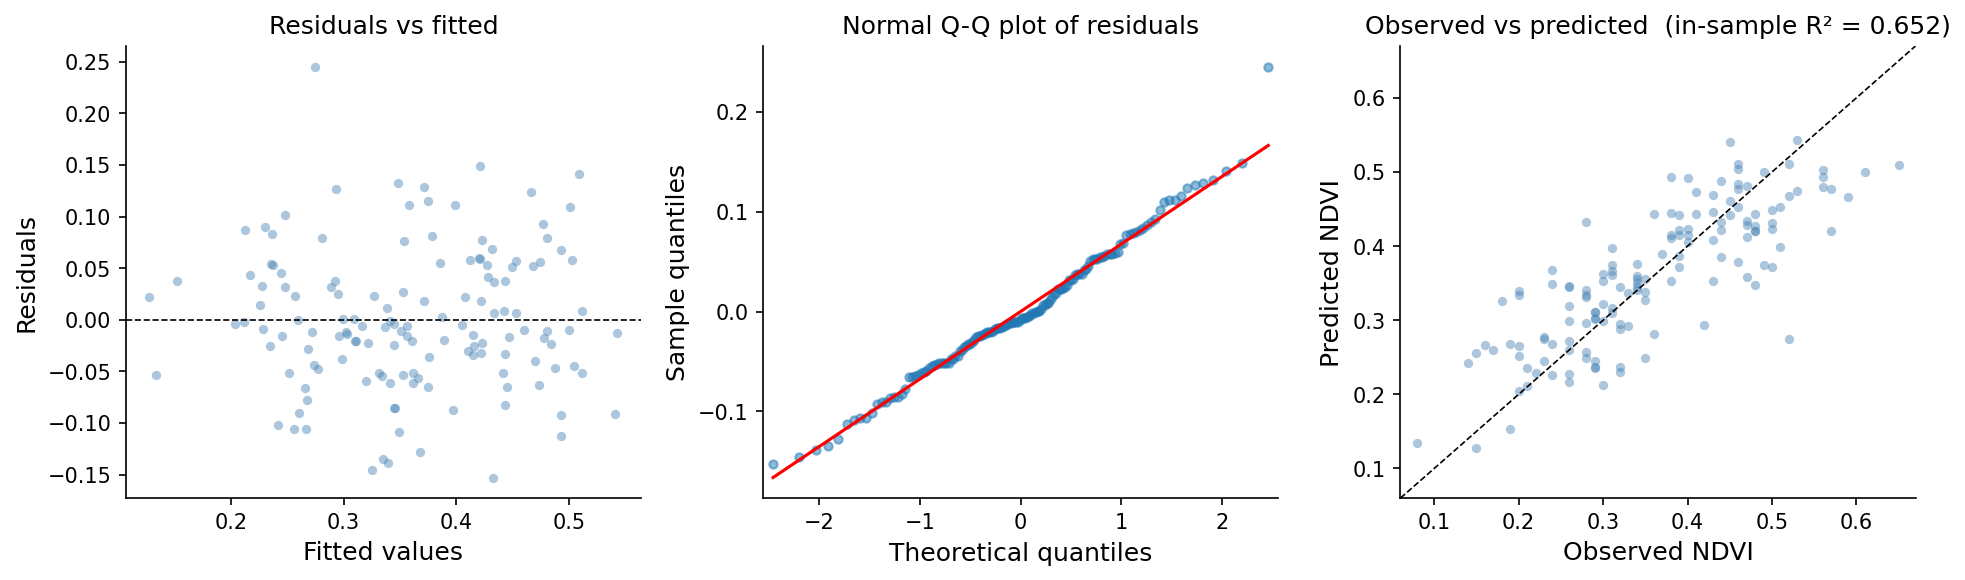

Saved: fig_diagnostics.png


In [32]:
# Residual diagnostics
y_obs  = df['NDVI'].values
y_fit  = res.fittedvalues.values
resids = y_obs - y_fit

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Residuals vs fitted
axes[0].scatter(y_fit, resids, alpha=0.45, s=20, color='steelblue', linewidths=0)
axes[0].axhline(0, color='black', lw=0.8, ls='--')
axes[0].set_xlabel('Fitted values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs fitted')

# QQ plot
sm.qqplot(resids, line='s', alpha=0.5, ax=axes[1], markersize=4)
axes[1].set_title('Normal Q-Q plot of residuals')
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')

# Observed vs predicted
r2 = r2_score(y_obs, y_fit)
lim = [min(y_obs.min(), y_fit.min()) - 0.02,
       max(y_obs.max(), y_fit.max()) + 0.02]
axes[2].scatter(y_obs, y_fit, alpha=0.45, s=20, color='steelblue', linewidths=0)
axes[2].plot(lim, lim, 'k--', lw=0.8)
axes[2].set_xlim(lim); axes[2].set_ylim(lim)
axes[2].set_xlabel('Observed NDVI')
axes[2].set_ylabel('Predicted NDVI')
axes[2].set_title(f'Observed vs predicted  (in-sample R² = {r2:.3f})')

plt.tight_layout()
plt.savefig('fig_diagnostics.png', bbox_inches='tight', dpi=200)
plt.show()
print('Saved: fig_diagnostics.png')

### 6. Cross-validated R²

5-fold CV with alpha re-optimized on each training fold to avoid optimistic bias.

In [33]:
smooth_cols_m4 = ['it_elev_diff', 'Tsoil', 'ALD']
formula_m4_str = formula_m4  # defined in section 4

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_r2, cv_rmse = [], []

for fold_i, (train_idx, test_idx) in enumerate(cv.split(df)):
    df_train = df.iloc[train_idx].copy()
    df_test  = df.iloc[test_idx].copy()

    # Re-fit splines and re-optimize alpha on training fold only
    try:
        res_fold, alpha_fold, sp_fold = fit_gam(
            formula_m4_str, smooth_cols_m4, df_train
        )

        exog_test        = df_test[['SM_bin', 'abund_spcs', 'Site',
                                    'it_elev_diff', 'Tsoil', 'ALD']]
        exog_smooth_test = df_test[smooth_cols_m4]

        y_pred_fold = res_fold.predict(exog=exog_test, exog_smooth=exog_smooth_test)
        y_test      = df_test['NDVI'].values

        cv_r2.append(r2_score(y_test, y_pred_fold))
        cv_rmse.append(np.sqrt(np.mean((y_test - y_pred_fold)**2)))
        print(f'  Fold {fold_i+1}: R² = {cv_r2[-1]:.3f}, RMSE = {cv_rmse[-1]:.4f}')

    except Exception as e:
        print(f'  Fold {fold_i+1}: failed — {e}')

print()
print(f'5-fold CV R²  : {np.mean(cv_r2):.3f} ± {np.std(cv_r2):.3f}')
print(f'5-fold CV RMSE: {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}')

  Fold 1: R² = 0.445, RMSE = 0.0721
  Fold 2: R² = 0.576, RMSE = 0.0793
  Fold 3: failed — some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
  Fold 4: failed — some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)
  Fold 5: failed — some data points fall outside the outermost knots, and I'm not sure how to handle them. (Patches accepted!)

5-fold CV R²  : 0.511 ± 0.066
5-fold CV RMSE: 0.0757 ± 0.0036


### 7. Results summary table (for methods / supplementary)

In [34]:
# Summarize key model fit statistics
r2_insample = r2_score(y_obs, y_fit)

print('Model fit summary — M4')
print('=' * 55)
print(f'  n observations:          {len(df)}')
print(f'  AIC:                     {res.aic:.2f}')
print(f'  Log-likelihood:          {res.llf:.2f}')
print(f'  Residual df:             {res.df_resid:.2f}')
print(f'  Pseudo R² (Cox-Snell):   {1 - np.exp((res.llnull - res.llf) * 2 / len(df)):.3f}')
print(f'  In-sample R²:            {r2_insample:.3f}')
if cv_r2:
    print(f'  5-fold CV R²:            {np.mean(cv_r2):.3f} ± {np.std(cv_r2):.3f}')
    print(f'  5-fold CV RMSE:          {np.mean(cv_rmse):.4f} ± {np.std(cv_rmse):.4f}')
print()
print('Smoothing penalties (alpha):')
for col, alpha in zip(['it_elev_diff', 'Tsoil', 'ALD'], m4_alpha):
    print(f'  {col:<18}: {alpha:.4f}  {"(→ near linear)" if alpha > 10 else ""}')
print()
print('Collinearity note: ALD–Tsoil r = {:.3f}'.format(df['ALD'].corr(df['Tsoil'])))
print('Recommend reporting VIFs or acknowledging in limitations.')

Model fit summary — M4
  n observations:          142
  AIC:                     -322.00
  Log-likelihood:          180.94
  Residual df:             122.06
  Pseudo R² (Cox-Snell):   0.803
  In-sample R²:            0.652
  5-fold CV R²:            0.511 ± 0.066
  5-fold CV RMSE:          0.0757 ± 0.0036

Smoothing penalties (alpha):
  it_elev_diff      : 0.0086  
  Tsoil             : 1.1092  
  ALD               : 275.1868  (→ near linear)

Collinearity note: ALD–Tsoil r = 0.766
Recommend reporting VIFs or acknowledging in limitations.


### 8. Publication figure

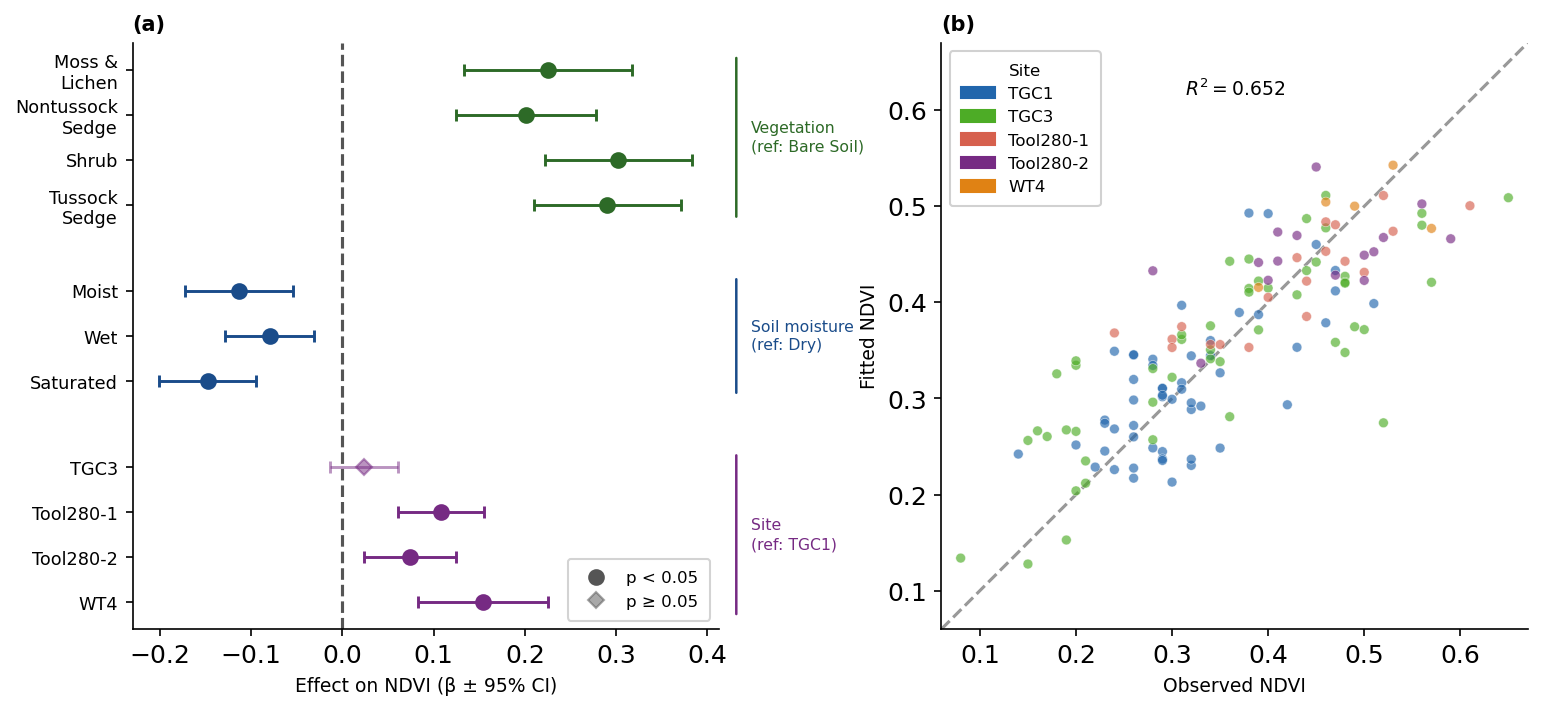

In [35]:
# Style
plt.rcParams.update({
    'font.family': 'sans-serif', 'font.size': 12,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 8, 'axes.linewidth': 0.8,
    'xtick.major.width': 0.8, 'ytick.major.width': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
})

VEG_COLORS = {
    'Shrub':            '#2d6a27',
    'Tussock Sedge':    '#5aaa50',
    'Moss and Lichen':  '#3a8fbf',
    'Nontussock Sedge': '#7ecec4',
    'Bare Soil':        '#c9a96e',
}
SM_COLORS = {
    'Dry':       '#d4a04a',
    'Moist':     '#7cbe7c',
    'Wet':       '#4a8cbf',
    'Saturated': '#1a4c8a',
}
SITE_COLORS = {
    'TGC1':      '#2166ac',
    'TGC3':      '#4dac26',
    'Tool280-1': '#d6604d',
    'Tool280-2': '#762a83',
    'WT4':       '#e08214',
}
SITE_ORDER = ['TGC1', 'TGC3', 'Tool280-1', 'Tool280-2', 'WT4']

# Fit M4 (with continuous linear terms in formula)
x_smooth = df[['it_elev_diff', 'Tsoil', 'ALD']].values
smoother = BSplines(x_smooth, df=[4, 4, 4], degree=[3, 3, 3])
formula = ('NDVI ~ C(SM_bin, Treatment("Dry")) + '
           'C(abund_spcs, Treatment("Bare Soil")) + '
           'C(Site, Treatment("TGC1")) + '
           'it_elev_diff + Tsoil + ALD')
gam_init = GLMGam.from_formula(formula, data=df, smoother=smoother, alpha=[1, 1, 1])
gam_init.fit()
opt = gam_init.select_penweight()[0]
res = GLMGam.from_formula(formula, data=df, smoother=smoother, alpha=opt).fit()
y_obs = df['NDVI'].values
y_fit = res.fittedvalues.values
r2 = r2_score(y_obs, y_fit)

cont_means = {c: df[c].mean() for c in ['it_elev_diff', 'Tsoil', 'ALD']}

# Prediction helpers
_SM_levels   = [l for l in sorted(df['SM_bin'].unique())     if l != 'Dry']
_VEG_levels  = [l for l in sorted(df['abund_spcs'].unique()) if l != 'Bare Soil']
_SITE_levels = [l for l in sorted(df['Site'].unique())       if l != 'TGC1']
_all_col_names   = res.model.exog_names
_n_smooth_cols   = smoother.transform(x_smooth[:1]).shape[1]
_param_col_names = _all_col_names[:-_n_smooth_cols]

def _build_X(rows_df):
    n = len(rows_df)
    cols = {'Intercept': np.ones(n)}
    for lvl in _SM_levels:
        cols[f'C(SM_bin, Treatment("Dry"))[T.{lvl}]'] = (rows_df['SM_bin'].values == lvl).astype(float)
    for lvl in _VEG_levels:
        cols[f'C(abund_spcs, Treatment("Bare Soil"))[T.{lvl}]'] = (rows_df['abund_spcs'].values == lvl).astype(float)
    for lvl in _SITE_levels:
        cols[f'C(Site, Treatment("TGC1"))[T.{lvl}]'] = (rows_df['Site'].values == lvl).astype(float)
    X_param  = np.column_stack([cols[c] for c in _param_col_names]).astype(float)
    X_smooth = smoother.transform(rows_df[['it_elev_diff', 'Tsoil', 'ALD']].values.astype(float))
    return np.hstack([X_param, X_smooth])

# Figure
fig, (ax_L, ax_R) = plt.subplots(1, 2, figsize=(12, 6.5),
                                   gridspec_kw={'wspace': 0.38})

#===========
#  Panel A == Model effect plot
#===========
coef_groups = {
    ('Vegetation', 'ref: Bare Soil', '#2d6a27'): {
        'Moss &\nLichen':    'C(abund_spcs, Treatment("Bare Soil"))[T.Moss and Lichen]',
        'Nontussock\nSedge': 'C(abund_spcs, Treatment("Bare Soil"))[T.Nontussock Sedge]',
        'Shrub':             'C(abund_spcs, Treatment("Bare Soil"))[T.Shrub]',
        'Tussock\nSedge':    'C(abund_spcs, Treatment("Bare Soil"))[T.Tussock Sedge]',
    },
    ('Soil moisture', 'ref: Dry', '#1a4c8a'): {
        'Moist':     'C(SM_bin, Treatment("Dry"))[T.Moist]',
        'Wet':       'C(SM_bin, Treatment("Dry"))[T.Wet]',
        'Saturated': 'C(SM_bin, Treatment("Dry"))[T.Saturated]',
    },
    ('Site', 'ref: TGC1', '#762a83'): {
        'TGC3':      'C(Site, Treatment("TGC1"))[T.TGC3]',
        'Tool280-1': 'C(Site, Treatment("TGC1"))[T.Tool280-1]',
        'Tool280-2': 'C(Site, Treatment("TGC1"))[T.Tool280-2]',
        'WT4':       'C(Site, Treatment("TGC1"))[T.WT4]',
    },
}

ci_all = res.conf_int()
params = res.params
pvals  = res.pvalues
yticks, ylabels = [], []
group_spans = []
y_pos = 0

for (gname, gref, gcolor), coefs in coef_groups.items():
    g_start = y_pos
    for label, cname in coefs.items():
        if cname not in params.index:
            continue
        est = params[cname]
        lo  = ci_all.loc[cname, 0]
        hi  = ci_all.loc[cname, 1]
        p   = pvals[cname]
        mk  = 'o' if p < 0.05 else 'D'
        ms  = 7   if p < 0.05 else 5.5
        al  = 1.0 if p < 0.05 else 0.5
        ax_L.errorbar(est, y_pos,
                      xerr=[[est - lo], [hi - est]],
                      fmt=mk, color=gcolor, capsize=3,
                      markersize=ms, elinewidth=1.4, capthick=1.4, alpha=al)
        yticks.append(y_pos); ylabels.append(label)
        y_pos += 1
    group_spans.append((g_start, y_pos - 1, gname, gref, gcolor))
    y_pos += 0.9

ax_L.axvline(0, color='#555555', lw=1.5, ls='--', zorder=0)
ax_L.set_yticks(yticks)
ax_L.set_yticklabels(ylabels, fontsize=8.5)
ax_L.set_xlabel('Effect on NDVI (β ± 95% CI)', fontsize=9)
ax_L.set_title('(a)', loc='left', fontweight='bold', fontsize=10)
ax_L.invert_yaxis()
ax_L.spines['top'].set_visible(False)
ax_L.spines['right'].set_visible(False)
ax_L.set_box_aspect(1)

# Group bracket labels on the right
trans = mtransforms.blended_transform_factory(ax_L.transAxes, ax_L.transData)
for y0, y1, gname, gref, gcolor in group_spans:
    ymid = (y0 + y1) / 2
    ax_L.annotate('', xy=(1.03, y0 - 0.35), xytext=(1.03, y1 + 0.35),
                  xycoords=trans, textcoords=trans,
                  arrowprops=dict(arrowstyle='-', color=gcolor, lw=1.2),
                  annotation_clip=False)
    ax_L.text(1.055, ymid, f'{gname}\n({gref})',
              transform=trans, fontsize=7.5, color=gcolor,
              va='center', ha='left', clip_on=False, linespacing=1.3)

leg_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555',
           markeredgecolor='#555', markersize=7, label='p < 0.05'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='#555',
           markeredgecolor='#555', markersize=5.5, alpha=0.5, label='p ≥ 0.05'),
]
ax_L.legend(handles=leg_handles, loc='lower right', framealpha=0.85,
            fontsize=8, borderpad=0.7)

#===========
# Panel B == Observed vs Fitted
#===========
site_c = [SITE_COLORS[s] for s in df['Site']]
ax_R.scatter(y_obs, y_fit, c=site_c, alpha=0.65, s=22,
             linewidths=0.3, edgecolors='white', zorder=3)
lo_lim = min(y_obs.min(), y_fit.min()) - 0.02
hi_lim = max(y_obs.max(), y_fit.max()) + 0.02
ax_R.plot([lo_lim, hi_lim], [lo_lim, hi_lim], '--', color='#555555',
          lw=1.5, alpha=0.6, zorder=2)
ax_R.set_xlabel('Observed NDVI', fontsize=9)
ax_R.set_ylabel('Fitted NDVI', fontsize=9)
ax_R.set_title('(b)', loc='left', fontweight='bold', fontsize=10)
ax_R.set_xlim(lo_lim, hi_lim)
ax_R.set_ylim(lo_lim, hi_lim)
ax_R.set_box_aspect(1)
ax_R.text(0.5, 0.94, f'$R^2 = {r2:.3f}$', transform=ax_R.transAxes,
          fontsize=9, va='top', ha='center')
ax_R.spines['top'].set_visible(False)
ax_R.spines['right'].set_visible(False)

site_handles = [mpatches.Patch(color=SITE_COLORS[s], label=s) for s in SITE_ORDER]
ax_R.legend(handles=site_handles, title='Site', title_fontsize=8,
            fontsize=8, loc='upper left', framealpha=0.9, borderpad=0.7)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.savefig('fig_pub_combined_02.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.savefig('fig_combined_02.pdf', bbox_inches='tight', facecolor='white')
plt.show()

### 9. Full GAM term significance table

A single table covering every term in the model: smooth terms, categorical predictors, 
and continuous linear components. This is the table to include as a supplementary table (S1) in the publication.


In [36]:
#  Helper functions: format p-values
def fmt_p(p):
    if p < 0.001: return '< 0.001'
    return f'{p:.3f}'

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'


rows = []

#===========
# 1. Smooth terms == joint significance via Wald test on spline basis coefs
#===========
# For each smoother, the basis coefficients are x0_s*, x1_s*, x2_s*
# We test the joint null that all basis coefs = 0 using a chi-squared Wald test
smooth_info = [
    ('Relative incision', 'it_elev_diff', ['x0_s0','x0_s1','x0_s2'], res.params['it_elev_diff'], res.pvalues['it_elev_diff']),
    ('Soil temperature',  'Tsoil',        ['x1_s0','x1_s1','x1_s2'], res.params['Tsoil'],        res.pvalues['Tsoil']),
    ('Active layer depth','ALD',           ['x2_s0','x2_s1','x2_s2'], res.params['ALD'],          res.pvalues['ALD']),
]

for label, lin_name, spline_names, lin_coef, lin_p in smooth_info:
    # Joint Wald test: linear + spline basis coefs together
    all_names = [lin_name] + spline_names
    idx = [list(res.params.index).index(n) for n in all_names]
    beta_sub = res.params.values[idx]
    cov_sub  = res.cov_params().values[np.ix_(idx, idx)]
    W = beta_sub @ np.linalg.solve(cov_sub, beta_sub)
    df_wald = len(idx)
    p_wald = stats.chi2.sf(W, df=df_wald)

    # Optimal alpha for this smoother
    smooth_col_order = ['it_elev_diff', 'Tsoil', 'ALD']
    alpha_i = m4_alpha[smooth_col_order.index(lin_name)]

    rows.append({
        'Term':        label,
        'Type':        'Smooth (penalized spline)',
        'Level':       '—',
        'Estimate':    '—',
        '95% CI':      '—',
        'z / χ²':      f'χ²({df_wald}) = {W:.2f}',
        'p (raw)':     fmt_p(p_wald),
        'Sig':         sig_stars(p_wald),
        'Note':        f'α = {alpha_i:.3f}; linear component p = {fmt_p(lin_p)}',
    })

#===========
# 2. Categorical terms == each level vs reference, then group-level F-test
#===========
ci_all = res.conf_int()

def add_categorical_group(group_label, term_type, coef_prefix, levels_ordered, ref_label):
    """Add one row per non-reference level, then a group omnibus row."""
    group_coef_names = [c for c in res.params.index if coef_prefix in c]

    # Individual level rows
    for coef_name in group_coef_names:
        # Parse level name from coef string  e.g. '[T.Shrub]'
        level = coef_name.split('[T.')[1].rstrip(']')
        est   = res.params[coef_name]
        lo    = ci_all.loc[coef_name, 0]
        hi    = ci_all.loc[coef_name, 1]
        z     = res.tvalues[coef_name]
        p     = res.pvalues[coef_name]
        rows.append({
            'Term':       group_label,
            'Type':       term_type,
            'Level':      f'{level} vs {ref_label}',
            'Estimate':   f'{est:+.4f}',
            '95% CI':     f'[{lo:+.4f}, {hi:+.4f}]',
            'z / χ²':     f'z = {z:+.3f}',
            'p (raw)':    fmt_p(p),
            'Sig':        sig_stars(p),
            'Note':       '',
        })

    # Group omnibus Wald test (all levels jointly = 0)
    idx_g = [list(res.params.index).index(n) for n in group_coef_names]
    beta_g = res.params.values[idx_g]
    cov_g  = res.cov_params().values[np.ix_(idx_g, idx_g)]
    W_g = beta_g @ np.linalg.solve(cov_g, beta_g)
    p_g = stats.chi2.sf(W_g, df=len(idx_g))
    rows.append({
        'Term':       group_label,
        'Type':       term_type,
        'Level':      f'OMNIBUS ({len(idx_g)} df)',
        'Estimate':   '—',
        '95% CI':     '—',
        'z / χ²':     f'χ²({len(idx_g)}) = {W_g:.2f}',
        'p (raw)':    fmt_p(p_g),
        'Sig':        sig_stars(p_g),
        'Note':       'Joint Wald test',
    })

add_categorical_group(
    'Vegetation type', 'Parametric (categorical)',
    'C(abund_spcs', None, 'Bare Soil'
)
add_categorical_group(
    'Soil moisture', 'Parametric (categorical)',
    'C(SM_bin', None, 'Dry'
)
add_categorical_group(
    'Site', 'Parametric (categorical)',
    'C(Site', None, 'TGC1'
)

#===========
# 3. Print the table
#===========
tbl = pd.DataFrame(rows)[['Term','Type','Level','Estimate','95% CI','z / χ²','p (raw)','Sig','Note']]

# Pretty-print
print('Table 1. GAM term significance summary — Model M4')
print(f'Response: NDVI  |  n = {len(df)}  |  AIC = {res.aic:.1f}  |  In-sample R² = {r2_score(y_obs, y_fit):.3f}')
print('─' * 120)
header = f'{"Term":<22} {"Type":<28} {"Level":<30} {"Est":>8} {"95% CI":>22} {"z/χ²":>18} {"p":>8} {"Sig":>4}'
print(header)
print('─' * 120)
for _, row in tbl.iterrows():
    est_str = row['Estimate'] if row['Estimate'] == '—' else row['Estimate']
    ci_str  = row['95% CI']  if row['95% CI']  == '—' else row['95% CI']
    is_omnibus = 'OMNIBUS' in str(row['Level'])
    prefix = '  → ' if (row['Level'] != '—' and not is_omnibus) else ''
    line = (f"{row['Term']:<22} {row['Type']:<28} "
            f"{prefix}{row['Level']:<26} {est_str:>8} "
            f"{ci_str:>22} {row['z / χ²']:>18} {row['p (raw)']:>8} {row['Sig']:>4}")
    if is_omnibus:
        print('  ' + '·' * 116)
    print(line)
    if row['Note']:
        print(f'{"":>80}  [{row["Note"]}]')
print('─' * 120)
print('Significance: *** p < 0.001, ** p < 0.01, * p < 0.05, ns = not significant')
print('p values for individual levels are NOT Holm-corrected (see Section 9 for corrected pairwise contrasts)')

#===========
# 4. Export as CSV
#===========
tbl.to_csv('table1_gam_terms.csv', index=False)
print('\nSaved: table01_gam_terms.csv')


Table 1. GAM term significance summary — Model M4
Response: NDVI  |  n = 142  |  AIC = -322.0  |  In-sample R² = 0.652
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Term                   Type                         Level                               Est                 95% CI               z/χ²        p  Sig
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Relative incision      Smooth (penalized spline)    —                                 —                      —      χ²(4) = 20.59  < 0.001  ***
                                                                                  [α = 0.009; linear component p = 0.003]
Soil temperature       Smooth (penalized spline)    —                                 —                      —      χ²(4) = 22.72  < 0.001  ***
                                                                                 

In [37]:
#Get the model 4 stuff
opt = m4_alpha

# OR define it directly from the fitted model
#opt = res.model.alpha  # the alpha used in the final fitted model
def fmt_p(p):
    if p < 0.001: return '<0.001'
    return f'{p:.3f}'

def sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def wald_test(param_names, params, cov):
    """Joint Wald chi-squared test: H0 = all named coefficients are zero."""
    idx = [list(params.index).index(n) for n in param_names]
    b = params.values[idx]
    V = cov.values[np.ix_(idx, idx)]
    W = b @ np.linalg.solve(V, b)
    p = stats.chi2.sf(W, df=len(idx))
    return W, len(idx), p

ci     = res.conf_int()
params = res.params
pvals  = res.pvalues
tvals  = res.tvalues
cov    = res.cov_params()

# Smooth terms: linear component + spline basis coefs (x0_s*, x1_s*, x2_s*)
# Column order matches the smoother: [it_elev_diff, Tsoil, ALD]
smooth_defs = [
    ('s(Relative incision)',  'it_elev_diff', ['x0_s0','x0_s1','x0_s2'], opt[0]),
    ('s(Soil temperature)',   'Tsoil',        ['x1_s0','x1_s1','x1_s2'], opt[1]),
    ('s(Active layer depth)', 'ALD',          ['x2_s0','x2_s1','x2_s2'], opt[2]),
]

# Categorical terms in model order
cat_defs = [
    ('Vegetation type', [n for n in params.index if 'abund_spcs' in n]),
    ('Soil moisture',   [n for n in params.index if 'SM_bin'     in n]),
    ('Site',            [n for n in params.index if 'Site'       in n]),
]

rows = []

# Smooth terms: one omnibus row per smoother
for label, lin_name, spline_names, alpha_val in smooth_defs:
    W, df_w, p_w = wald_test([lin_name] + spline_names, params, cov)
    lin_est = params[lin_name]
    lin_lo, lin_hi = ci.loc[lin_name, 0], ci.loc[lin_name, 1]
    rows.append({
        'Term':        label,
        'Level':       '—',
        'β':           f'{lin_est:+.4f}',
        '95% CI':      f'[{lin_lo:+.4f}, {lin_hi:+.4f}]',
        'Test stat':   f'χ²({df_w}) = {W:.2f}',
        'p':           fmt_p(p_w),
        'Sig':         sig(p_w),
        'Penalty (α)': f'{alpha_val:.3f}',
    })

# Categorical terms: omnibus row then one row per level
for group_label, coef_names in cat_defs:
    W, df_w, p_w = wald_test(coef_names, params, cov)
    rows.append({
        'Term':        group_label,
        'Level':       f'[omnibus, {df_w} df]',
        'β':           '—',
        '95% CI':      '—',
        'Test stat':   f'χ²({df_w}) = {W:.2f}',
        'p':           fmt_p(p_w),
        'Sig':         sig(p_w),
        'Penalty (α)': '—',
    })
    for cn in coef_names:
        level = cn.split('[T.')[1].rstrip(']')
        est   = params[cn]
        lo, hi = ci.loc[cn, 0], ci.loc[cn, 1]
        rows.append({
            'Term':        '',
            'Level':       f'  {level}',
            'β':           f'{est:+.4f}',
            '95% CI':      f'[{lo:+.4f}, {hi:+.4f}]',
            'Test stat':   f'z = {tvals[cn]:+.3f}',
            'p':           fmt_p(pvals[cn]),
            'Sig':         sig(pvals[cn]),
            'Penalty (α)': '—',
        })

tbl = pd.DataFrame(rows)
print(f"\nTable 1. GAM term summary (M4)  |  n = {len(df)}  |  AIC = {res.aic:.1f}  |  R² = {r2_insample:.3f}\n")
print(tbl.to_string(index=False))
print("\nReference levels: Vegetation = Bare Soil, Soil moisture = Dry, Site = TGC1")
print("β for smooth terms is the linear component only; omnibus test covers linear + spline basis jointly.")
print("Sig: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant")

# Optional: save to CSV for journal submission
tbl.to_csv('table02_gam_terms.csv', index=False)


Table 1. GAM term summary (M4)  |  n = 142  |  AIC = -322.0  |  R² = 0.652

                 Term              Level       β             95% CI     Test stat      p Sig Penalty (α)
 s(Relative incision)                  — -0.0569 [-0.0941, -0.0198] χ²(4) = 20.59 <0.001 ***       0.009
  s(Soil temperature)                  — +0.0135 [+0.0029, +0.0240] χ²(4) = 22.72 <0.001 ***       1.109
s(Active layer depth)                  — +0.0011 [-0.0027, +0.0048]  χ²(4) = 5.98  0.201  ns     275.187
      Vegetation type    [omnibus, 4 df]       —                  — χ²(4) = 76.67 <0.001 ***           —
                         Moss and Lichen +0.2255 [+0.1336, +0.3175]    z = +4.807 <0.001 ***           —
                        Nontussock Sedge +0.2012 [+0.1244, +0.2780]    z = +5.135 <0.001 ***           —
                                   Shrub +0.3024 [+0.2217, +0.3831]    z = +7.343 <0.001 ***           —
                           Tussock Sedge +0.2901 [+0.2097, +0.3706]    z = +7.069 <